In [27]:
import pickle
import numpy as np
import os
import tqdm
import torch
import gc

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

from importlib import reload
from matplotlib import pyplot as plt

import matrix_approx_zeshel

matrix_approx_zeshel = reload(matrix_approx_zeshel)

!ls  | grep matrix_approx_zeshel

matrix_approx_zeshel.py


In [28]:
!uname -a

Linux insight.vla.yp-c.yandex.net 5.4.210-39.1.pagevecsize #1 SMP Tue Jul 18 16:14:52 UTC 2023 x86_64 x86_64 x86_64 GNU/Linux


In [29]:
# !pip install tensorflow_ranking

# Open Data loader & context

In [30]:
def load_ment_to_ent_scores(directory = "yugioh", shuffle_rows = 0, full = True):
    data = list()

    for file in os.listdir(directory):
        path = f"{directory}/{file}"
        print(f"Loading file {path}")
        with open(path, "rb") as f:
            data.append(
                pickle.load(f)
            )
    data = sorted(data, key = lambda x: x["arg_dict"]["n_ment_start"])

    for i in range(len(data) - 1):
        if full:
            assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] == data[i + 1]["arg_dict"]["n_ment_start"]
        else:
            assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] <= data[i + 1]["arg_dict"]["n_ment_start"]
        
    ment_to_ent_scores = list(map(lambda x: x["ment_to_ent_scores"], data))
    ment_to_ent_scores = np.vstack(ment_to_ent_scores)
    print("Loaded shape = ", ment_to_ent_scores.shape)
    
    if shuffle_rows:
        print(f"Shuffling... (seed = {shuffle_rows})")
        np.random.seed(shuffle_rows)
        np.random.shuffle(ment_to_ent_scores)
    
    return ment_to_ent_scores

In [31]:
from sklearn.cluster import KMeans

def from_labels(X, labels):
    K = list()
    for i in range(100):
        sl_i = np.arange(X.shape[0])[labels == i]
        sl = X[labels == i]
        
        if len(sl_i) == 0:
            # bug-mode
            while True:
                chosen = np.random.choice(np.arange(X.shape[0])[labels < i], size=1)[0]
                if chosen not in K:
                    K.append(chosen)
                    break
            continue
            
        center = sl.mean(axis=0).reshape(1, -1)
        best = euclidean_distances(sl, center).argmin()
        K.append(sl_i[best])
        assert labels[K[-1]] == i
    return K

class EvalContextRelevs:
    def __init__(self, relevs, key_size = 100, train_size = 0.7, key_games = None, seed = 17, shuffle=False, det_attempts = 0):
        self.relevs = np.array(relevs)
        self.reqs_count = self.relevs.shape[0]
        self.games_count = self.relevs.shape[1]
        
        self.key_size = key_size
        self.key_games = (
            np.random.choice(np.arange(self.games_count), key_size, replace=False)
            if key_games is None else
            key_games
        )
        np.random.seed(seed)
        if shuffle:
            np.random.shuffle(self.relevs)

        self.try_det_attempts(det_attempts)
        self.train_split = int(self.reqs_count * train_size)

        assert key_size + 1 < self.train_split


        self.key_relevs = self.relevs[:key_size]
        self.train_relevs = self.relevs[key_size + 1: self.train_split]
        self.test_relevs = self.relevs[self.train_split:]

        self.slices = ["key", "train", "test"]
        print(len(self.key_relevs), len(self.train_relevs), len(self.test_relevs))

    def get_top_games(self):
        return self.relevs.mean(axis=0).argsort()[:100]

    def set_top_games_as_key(self):
        self.key_games = self.get_top_games()
        return self

    def get_kmeans_games(self, all_from_labels=True):
        X = self.get_relevs("train").T

        k_func = (
            (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
            if not all_from_labels else
            (lambda C : from_labels(X, C.labels_))
        )
        K_KMeans = k_func(
            KMeans(n_clusters=self.key_size, random_state=0).fit(X)  #, n_init="auto").fit(X)
        )
        
        return K_KMeans
    
    def set_kmeans_games_as_key(self, *args, **kwargs):
        self.key_games = self.get_kmeans_games(*args, **kwargs)
        return self
    

    def try_det_attempts(self, det_attempts):
        def get_det(r):
            kr = r[:self.key_size, self.key_games] - r.mean()
            return np.abs(np.linalg.det(kr))

        best_i_array = np.arange(len(self.relevs))

        for i in range(det_attempts):

            r_i_array = np.arange(len(self.relevs))
            np.random.shuffle(r_i_array)

            n, o = get_det(self.relevs[r_i_array, :]), get_det(self.relevs[best_i_array, :])
            
            # print(f"try update key_reqs ({o} vs {n}...")
            if n > o:
                best_i_array = r_i_array
                print(f"updated det ({i}, {o} -> {n})")

        print("Best det = ", get_det(self.relevs[best_i_array, :]))

        self.relevs = self.relevs[best_i_array, :]
        print("Current de = ", get_det(self.relevs))
        
    def get_relevs(self, t = "train"):
        if t == "train":
            return self.train_relevs
        elif t == "key":
            return self.key_relevs
        elif t == "test":
            return self.test_relevs
        else:
            assert False
            
    def get_requests(self, t = "train"):
        if t == "train":
            return self.train_reqs
        elif t == "key":
            return self.key_reqs
        elif t == "test":
            return self.test_reqs
        else:
            assert False

# Games Data loader & context

In [32]:
import collections
import pickle
import numpy as np
import tqdm
import os
import gc

import matplotlib.pyplot as plt


def load(limit, raw_path = "stand/log.local.logtime2.txt", path = "log.local.logtime2.bin", key_games = None, seed = 17, det_attempts = 0):
    readvector = lambda s : np.array(list(map(float, s.strip()[1:-2].split(","))))
    requests = list()
    docembs = collections.defaultdict(dict)

    if os.path.isfile(path):
        with open(path, "rb") as f:
            flimit, frequests, fdocembs = pickle.load(f)
            if flimit == limit:
                requests, docembs = frequests, fdocembs
            else:
                print(f"WARN: buffered limit is different, {flimit} != {limit}, reloading...")

    if not requests:
        with open(raw_path) as f:
            req = list()
            reqid = None
            models = list()
            prevreqmodel = None
            reqmodel = dict()
            prevmodelid = -1
            bannermodelid = -1
            for i, line in tqdm.tqdm_notebook(enumerate(f)):
                if line.startswith("Model = 6;"):
                    prevreqmodel = reqmodel
                    reqmodel = dict()

                if line.startswith("Model = "):
                    spl = line.split(" ")
                    prevmodelid = int(spl[2][:-1])
                    bannermodelid = max(bannermodelid , prevmodelid)
                    reqmodel[prevmodelid] = readvector(spl[3])
                elif line.startswith("dbid"):
                    spl = line.split(" ")
                    dbid = int(spl[1][:-1])
                    docembs[bannermodelid][dbid] = readvector(spl[2])
                elif line.startswith("seed"):
                    if len(requests) >= limit:
                        break
                    if req:
                        requests.append((reqid, prevreqmodel, sorted(req)))
                        req = list()
                    reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
                else:
                    req.append(
                        (int(line.split()[0]), float(line.split()[1]))
                    )
        
        with open(path, "wb") as f:
            pickle.dump((limit, requests, docembs), f)

    games_count = len(requests[0][2])
    assert games_count == 16514
    requests = [r for r in requests if len(r[2]) == games_count]
    
    print([(i, len(docembs[i].keys())) for i in docembs])  # should be equal
    docblocks = {
        mid : np.array([x[1] for x in sorted(list(docembs[mid].items()))])
        for mid in docembs
    }
    
    class EvalContext:
        def __init__(self, games_count = games_count, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
            self.games_count = games_count
            
            self.key_size = key_size
            self.key_games = (
                np.random.choice(np.arange(games_count), key_size, replace=False)
                if key_games is None else
                key_games
            )

            self.requests = requests
            np.random.seed(seed)
            np.random.shuffle(self.requests)
            
            self.try_det_attempts(det_attempts)

            self.key_reqs = self.requests[:key_size + 1]
            self.key_reqs_idx = np.arange(key_size + 1)

            self.train_split = int(len(self.requests) * train_size)

            assert key_size + 1 < self.train_split

            self.train_reqs = self.requests[key_size + 1: self.train_split]
            self.test_reqs = self.requests[self.train_split:]

            self.slices = ["key", "train", "test"]
            print(len(self.key_reqs), len(self.train_reqs), len(self.test_reqs))

            self.docblocks = docblocks
            self.relevs = dict()
            
        def get_top_games(self):
            if not hasattr(self, "top_games"):
                embed_games = np.array([
                    np.array([r[2][g_i][1] for r in self.get_requests("train")])
                    for g_i in range(self.games_count)
                ])

                self.embed_games_mean = embed_games.mean(axis=1)
                self.top_games_all = (-self.embed_games_mean).argsort()
                self.top_games = self.top_games_all[:len(self.key_games)]

            return self.top_games
        
        def set_top_games_as_key(self):
            self.key_games = self.get_top_games()
            return self
        
        def get_kmeans_games(self, all_from_labels=True):
            X = self.get_relevs("train").T

            k_func = (
                (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
                if not all_from_labels else
                (lambda C : from_labels(X, C.labels_))
            )
            K_KMeans = k_func(
                KMeans(n_clusters=self.key_size, random_state=0).fit(X)  #, n_init="auto").fit(X)
            )

            return K_KMeans

        def set_kmeans_games_as_key(self, *args, **kwargs):
            self.key_games = self.get_kmeans_games(*args, **kwargs)
            return self

        def try_det_attempts(self, det_attempts, model_id = 6):
            def get_det(r, r_i_array):
                kr = np.array([
                    r[r_i][1][model_id]
                    for r_i in r_i_array[:100]
                ])
                return np.abs(np.linalg.det(kr[:kr.shape[1], :]))

            best_i_array = np.arange(len(self.requests))

            for _ in range(det_attempts):
                # print("try update key_reqs...")
                
                r_i_array = np.arange(len(self.requests))
                np.random.shuffle(r_i_array)
                
                n, o = get_det(self.requests, r_i_array), get_det(self.requests, best_i_array)
                # print(n, o)
                if n > o:
                    best_i_array = r_i_array
                    # print("updated!")

            print("Best det = ", get_det(self.requests, best_i_array))
            
            new_requests = [
                self.requests[i]
                for i in best_i_array
            ]
            
            del self.requests
            gc.collect()

            self.requests = new_requests
            print(get_det(self.requests, np.arange(len(self.requests))))

        def get_relevs(self, t = "train"):
            if t not in self.relevs:
                self.relevs[t] = np.array([
                    np.array([g_i[1] for g_i in r[2]])
                    for r in self.get_requests(t)
                ])
                
            return self.relevs[t]

        def get_requests(self, t = "train"):
            if t == "train":
                return self.train_reqs
            elif t == "key":
                return self.key_reqs
            elif t == "test":
                return self.test_reqs
            else:
                assert False

    return EvalContext(key_games = key_games, seed = seed, det_attempts = det_attempts)

# Models

In [33]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        self.trus_top = dict()
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):    
        recs = self.recommend(t)
        
        if isinstance(recs, list):
            recs = np.array(recs)
        
        mse = np.mean((recs - self.get_user_scores(t)) ** 2)
        
        if isinstance(recs, tf.Tensor):
            recs = tf.argsort(-recs, axis=1)[:, :topsize].numpy()
        else:
            recs = np.argsort(-recs, axis=1)[:, :topsize]
        
        if (t, topsize) not in self.trus_top:
            trus = self.get_user_scores(t)
            trus = np.argsort(-trus, axis=1)[:, :topsize]
            self.trus_top[(t, topsize)] = trus
            
        trus = self.trus_top[(t, topsize)]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [34]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "matrix_l2": 0,
    "dssm_l2": 0,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_matrix": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
    "activation": "relu",
    "score_verbose": 0,
    "trainable_items": False,
    "use_keys_in_train": False,
    "Winit": "glorot0.01",
    "Wfreeze": False,
    "TEinit": "legacy",
    "normalize_embs": True
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(fit_kwargs)
        self.fit_kwargs = p
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[i] for i in sorted(ctx.key_games)])
                    for r_i in ctx.get_relevs(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[g_i] for r in ctx.get_relevs("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        
        if self.fit_kwargs["trainable_items"]:
            if self.fit_kwargs["TEinit"] == "legacy":
                value = self.embed_games
            elif self.fit_kwargs["TEinit"] == "anncur":
                key_cols_idx = np.array(sorted(ctx.key_games))
                value = (
                    np.linalg.pinv(ctx.get_relevs("train")[:, key_cols_idx])
                    @ ctx.get_relevs("train")
                ).T
                print(type(value))
            else:
                assert False, "unknown TEinit: " + str(self.fit_kwargs["TEinit"])
                
            self.trainable_games = tf.Variable(
                tf.convert_to_tensor(value, dtype=tf.float32),
                trainable=True
            )
        else:
            if self.fit_kwargs["TEinit"] == "anncur":
                key_cols_idx = np.array(sorted(ctx.key_games))
                self.embed_games = (
                    np.linalg.pinv(ctx.get_relevs("train")[:, key_cols_idx])
                    @ ctx.get_relevs("train")
                ).T
                print("ANNCur init")
            
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = ctx.get_relevs("key")
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        if self.fit_kwargs["normalize_embs"]:
            return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        else:
            return self.embed_users[t]
    
    def get_game_embs(self):
        if not self.fit_kwargs["trainable_items"]:
            if self.fit_kwargs["normalize_embs"]:
                return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
            else:
                return self.embed_games 
        else:
            return self.trainable_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.p = p
        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_matrix = p["train_matrix"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        if p["use_keys_in_train"]:
            train_user_scores = np.vstack([
                self.get_user_scores("key"),
                self.get_user_scores("train")
            ])
            train_user_embs = np.vstack([
                self.get_user_embs("key"),
                self.get_user_embs("train")
            ])
        else:
            train_user_scores = self.get_user_scores("train")
            train_user_embs = self.get_user_embs("train")

        game_embs = self.get_game_embs()
        
        
        
        if self.p["Winit"] == "glorot0.01":
            initializer = tf.keras.initializers.GlorotUniform()
            values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
            values = values / 100.  
        elif self.p["Winit"] == "glorot":
            initializer = tf.keras.initializers.GlorotUniform()
            values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        elif self.p["Winit"] == "eye":
            values = np.eye(train_user_embs.shape[1], game_embs.shape[1])
        else:
            assert False, "init is not known:" + str(self.p["init"])
            
        self.W = tf.Variable(values, trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = (
                            game_embs[game_slice]
                            if isinstance(game_embs, np.ndarray) else
                            tf.gather(game_embs, game_slice)
                        )
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = 0
                    
                    if self.train_matrix:
                        logits += train_user_embs_ @ self.W @ tf.transpose(game_embs_)

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_signed":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    sf = tf.nn.softmax(logits, axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        sf,
                        -sf
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_sum(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                elif self.loss == "KL100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    mask = np.argsort(-scores, axis=1) < 100
                    v = tf.keras.losses.KLDivergence()((scores.T >= qs.T).T, logits)
                else:
                    assert False
                    
                if self.p["c"]:
                    v += tf.reduce_mean(self.W * self.W) * p["c"]
                    
                if self.p["dssm_l2"]:
                    for weights_ in [self.u_dssm.weights, self.g_dssm.weights]:
                        for weight_ in weights_:
                            v += tf.reduce_sum(weight_ * weight_) * self.p["dssm_l2"]
                
                if self.p["matrix_l2"]:
                    v += tf.reduce_sum(self.W * self.W) * self.p["matrix_l2"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            if self.train_matrix and (not self.p["Wfreeze"]):
                weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
            
            if self.p["trainable_items"]:
                weights += [self.trainable_games]
                
                
            opt.minimize(loss, weights)
            
            if p["score_verbose"] and (i % p["score_verbose"] == 0):
                print(f"\n=== Iteration {i} ===")
                for sl in self.ctx.slices:
                    print(f"slice = {sl}, score = {self.get_score(sl)}")
        print("last loss = ", loss())

    def recommend(self, t):
        logits = 0
                    
        if self.train_matrix:
            logits += self.get_user_embs(t) @ self.W @ tf.transpose(self.get_game_embs())

        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [35]:
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [36]:
class AnnCUR(Popular):
    def __init__(self, ctx, oracle=False, key_games=None, name=None):
        super().__init__(ctx)
        self.oracle = oracle
        self.ctx = ctx
        self.name = name

        self.key_cols_idx = np.array(sorted(ctx.key_games if key_games is None else key_games))
        rows_idx = np.arange(ctx.get_relevs("train").shape[0])
        
        self.cur = matrix_approx_zeshel.CURApprox(
            rows=torch.from_numpy(ctx.get_relevs("train")),
            cols=torch.from_numpy(ctx.get_relevs("train")[:, self.key_cols_idx]),
            row_idxs=rows_idx,
            col_idxs=self.key_cols_idx,
            approx_preference="rows",
            A=(torch.from_numpy(ctx.get_relevs("train")) if oracle else None)
        )        
        
    def __repr__(self):
        if self.name is None:
            return f"AnnCur({id(self)})"
        else:
            return f"AnnCur({self.name} - {id(self)})"
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        key_relevs = torch.from_numpy(self.ctx.get_relevs(t)[:, self.key_cols_idx])
        return self.cur.get_complete_row(key_relevs)
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

# Evals

In [37]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

def from_labels(X, labels):
    K = list()
    for i in range(100):
        sl_i = np.arange(X.shape[0])[labels == i]
        sl = X[labels == i]
        
        if len(sl_i) == 0:
            # bug-mode
            while True:
                chosen = np.random.choice(np.arange(X.shape[0])[labels < i], size=1)[0]
                if chosen not in K:
                    K.append(chosen)
                    break
            continue
            
        center = sl.mean(axis=0).reshape(1, -1)
        best = euclidean_distances(sl, center).argmin()
        K.append(sl_i[best])
        assert labels[K[-1]] == i
    return K

def K_by_min(X):
    center = X.mean(axis=0)
    K = [euclidean_distances(X, center.reshape(1, -1)).argmax()]

    while len(K) < 100:
        K.append(euclidean_distances(X, X[K]).min(axis=1).argmax())
    return K


def eval_clustering(ctx, all_from_labels=False):
    X = ctx.get_relevs("train").T
    from sklearn.cluster import KMeans
    
    k_func = (
        (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
        if not all_from_labels else
        (lambda C : from_labels(X, C.labels_))
    )
    
    K_KMeans = k_func(
        KMeans(n_clusters=100, random_state=0).fit(X)  #, n_init="auto").fit(X)
    )


    from sklearn.cluster import BisectingKMeans
    K_BisectingKMeans = k_func(
        BisectingKMeans(n_clusters=100, random_state=0).fit(X)
    )


    from sklearn.cluster import MiniBatchKMeans
    K_MiniBatchKMeans = from_labels(
        X,
        MiniBatchKMeans(n_clusters=100, random_state=0).fit(X).labels_
    )

    from sklearn.cluster import AgglomerativeClustering
    K_AgglomerativeClustering = from_labels(
        X,
        AgglomerativeClustering(n_clusters=100).fit(X).labels_
    )

    from sklearn.cluster import SpectralCoclustering
    K_SpectralCoclustering = from_labels(
        X,
        SpectralCoclustering(n_clusters=100, random_state=0).fit(X).row_labels_
    )

    from sklearn.cluster import SpectralBiclustering
    K_SpectralBiclustering = from_labels(
        X,
        SpectralBiclustering(n_clusters=100, random_state=0).fit(X).row_labels_
    )

    from sklearn.cluster import SpectralClustering
    K_SpectralClusteringNN = from_labels(
        X,
        SpectralClustering(n_clusters=100, random_state=0, affinity="nearest_neighbors", n_jobs=-1).fit(X).labels_
    )

    K_ByMin = K_by_min(X)

    ev([
        Popular(ctx),
        AnnCUR(ctx),
        AnnCUR(ctx, key_games=np.arange(100), name="key_games=np.arange(100)"),
        AnnCUR(ctx, key_games=np.random.choice(np.arange(X.shape[0]), size=100, replace=False), name="random"),
        AnnCUR(ctx, key_games=K_KMeans, name="K_KMeans"),
        AnnCUR(ctx, key_games=K_BisectingKMeans, name="K_BisectingKMeans"),
        AnnCUR(ctx, key_games=K_MiniBatchKMeans, name="K_MiniBatchKMeans"),
        AnnCUR(ctx, key_games=K_AgglomerativeClustering, name="K_AgglomerativeClustering"),
        AnnCUR(ctx, key_games=K_SpectralCoclustering, name="K_SpectralCoclustering"),
        AnnCUR(ctx, key_games=K_SpectralBiclustering, name="K_SpectralBiclustering"),
        AnnCUR(ctx, key_games=K_SpectralClusteringNN, name="K_SpectralClusteringNN"),
        AnnCUR(ctx, key_games=K_ByMin, name="K_ByMin"),
    ])

In [38]:
DATASETS = ["yugioh", "pro_wrestling", "star_trek", "doctor_who", "military"]

# support items choice

In [39]:
# setup:
# 1000 items, 1000 + 1000 queries
recall_k = 5
n_runs = 10
n_items_per_run = 1000
test_item_cnt = 100
item_cnt_range = list(range(5, 101, 5))
assert test_item_cnt in item_cnt_range

In [40]:
from collections import defaultdict
from itertools import combinations

from matplotlib import pyplot as plt
import numpy as np
import os
from sklearn.metrics import top_k_accuracy_score
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu, ttest_rel

In [41]:
#with open("collections_10000_items/test.npy", "rb") as fin:
#    all_test = np.load(fin)
#with open("collections_10000_items/train.npy", "rb") as fin:
#    all_train = np.load(fin)

#assert all_train.shape[0] == n_runs * n_items_per_run
#assert all_test.shape[0] == n_runs * n_items_per_run


In [42]:
def eval_items(items, train, test):
    item_embeds = train.dot(np.linalg.pinv(train[items]))
    approx_test_rel = item_embeds.dot(test[items])
    approx_train_rel = item_embeds.dot(train[items])
    best_items = np.argsort(test, axis=0)[-1]
    recall = top_k_accuracy_score(best_items, approx_test_rel.T, k=recall_k, labels=np.arange(train.shape[0]))
    test_mse = np.mean((test - approx_test_rel) ** 2)
    train_mse = np.mean((train - approx_train_rel) ** 2)
    return recall, test_mse, train_mse

def get_rnd_items(n_items, train):
    return np.random.choice(train.shape[0], n_items, replace=False)

def get_kmeans_items(n_items, train):
    kmeans = KMeans(n_clusters=n_items, n_init="auto").fit(train)
    items = []
    for center in kmeans.cluster_centers_:
        distances = ((train - center) ** 2).sum(axis=1)
        assert distances.shape == (train.shape[0],)
        for item_id in np.argsort(distances):
            if item_id not in items:
                items.append(item_id)
                break
    return np.array(items, dtype=np.int64)

greedy_items = []
def get_greedy(n_items, train, lazy=True):
    global greedy_items
    if not lazy:
        greedy_items = []
    if len(greedy_items) >= n_items:
        return np.array(greedy_items[:n_items], dtype=np.int64)
    
    gram = train.dot(train.T)
    gram /= gram.mean()
    items = []
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        scores = (gram ** 2).sum(axis=1)
        assert np.allclose(scores[~remaining_items], np.zeros_like(scores[~remaining_items])), (
            t, scores[~remaining_items]
        )
        scores[remaining_items] /= gram[remaining_items, remaining_items]
        if max(scores) < 1e-9:
            break
        new_item = scores.argmax()
        assert remaining_items[new_item]
        coefs = gram[new_item] / np.sqrt(gram[new_item, new_item])
        diff = coefs.reshape(-1, 1).dot(coefs.reshape(1, -1))
        gram -= diff
        assert np.allclose(gram[new_item], np.zeros_like(gram[new_item]), atol=1e-6), (
            t, gram[new_item].std()
        )
        items.append(new_item)
        remaining_items[new_item] = False
    assert len(items) == n_items
    greedy_items.clear()
    greedy_items.extend(items)
    return np.array(items, dtype=np.int64)


### fast-a

In [43]:
def coitem_algorithm(n_support, candidate_items, target_items, min_item_rel_norm=1e-5, eps=1e-6):
    support_items = []
    support_items_scores = []
    n_c, n_q = candidate_items.shape
    n_t = target_items.shape[0]

    candidate_item_squared_norms = (candidate_items ** 2).sum(axis=1)
    min_item_norm = min_item_rel_norm * np.sqrt(candidate_item_squared_norms.mean())
    
    candidate_coitems = candidate_items.dot(
        target_items.T.dot(target_items)
    )
    orthonormed_support_items = np.zeros((n_support, n_q))
    remaining_items = np.ones(candidate_items.shape[0], dtype="bool")
    for t in tqdm.tqdm_notebook(range(n_support)):
        scores = (candidate_coitems * candidate_items).sum(axis=1)
        remaining_items &= (candidate_item_squared_norms >= min_item_norm ** 2)
        scores[remaining_items] /= candidate_item_squared_norms[remaining_items]
        scores[~remaining_items] = 0
        
        new_item_id = np.argmax(scores)
        assert remaining_items[new_item_id]
        support_items.append(new_item_id)
        support_items_scores.append(scores[new_item_id] / (n_t * n_q))
        remaining_items[new_item_id] = False
        
        new_item = candidate_items[new_item_id].copy()
        new_item -= orthonormed_support_items[:t].T.dot(
            orthonormed_support_items[:t].dot(new_item)
        )
        assert np.allclose((new_item ** 2).sum(), candidate_item_squared_norms[new_item_id], atol=eps)
        new_item /= np.sqrt((new_item ** 2).sum())
        orthonormed_support_items[t] = new_item
        new_coitem = candidate_coitems[new_item_id] / np.sqrt(candidate_item_squared_norms[new_item_id])
        
        coefs = (candidate_items * new_item).sum(axis=1)
        candidate_item_squared_norms -= coefs ** 2
        assert np.all(candidate_item_squared_norms[remaining_items] > -eps)
        
        candidate_coitems -= coefs.reshape((-1, 1)).dot(new_coitem.reshape((1, -1)))
        cocoefs = (candidate_coitems * new_item).sum(axis=1, keepdims=True)
        candidate_coitems -= cocoefs.dot(new_item.reshape((1, -1)))
    return np.array(support_items, dtype=np.int64), np.array(support_items_scores)

In [44]:
# ctx.key_games

In [45]:
# !wget https://proxy.sandbox.yandex-team.ru/11620623193 > R9650_CE300.npz

In [46]:
!ls | grep CE

R1417_CE.npz
R3374_CE.npz
R9650_CE2K.npz
R9650_CE300.npz
R9650_CE3K__zeros_coitem.npz
R9650_CE.npz


In [47]:
from scipy.special import softmax

R = np.load('./R9650_CE.npz')
R_ = R["R"][:, :10000]  # using calculated part
# R_ = ((R_.T - R_.mean(axis=1)) / R_.std(axis=1)).T 
# R_ = softmax(R_, axis=1)
R_.shape

(9650, 10000)

(array([9.5152783e+07, 1.0379230e+06, 2.0738100e+05, 5.7551000e+04,
        2.0334000e+04, 9.3380000e+03, 5.4920000e+03, 4.2140000e+03,
        3.5780000e+03, 1.4060000e+03]),
 array([-11.53759956,  -9.22042847,  -6.90325737,  -4.58608675,
         -2.26891565,   0.04825544,   2.36542654,   4.68259764,
          6.99976826,   9.31693935,  11.63411045]),
 <BarContainer object of 10 artists>)

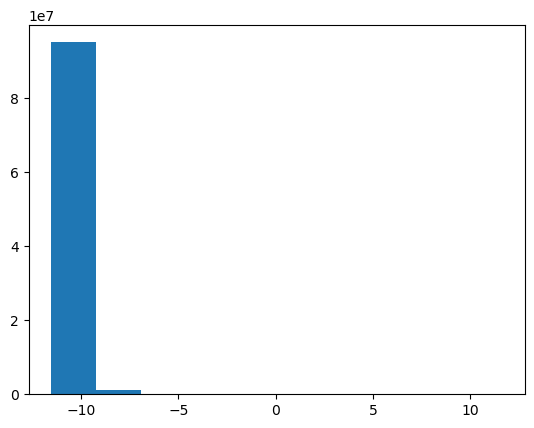

In [48]:
plt.hist(R_.flatten())

In [49]:
ctx = EvalContextRelevs(
    R_,
    det_attempts=0,
    shuffle=True
)

Best det =  1.03014716e-14
Current de =  1.03014716e-14
100 6654 2895


In [24]:
model = Popular(ctx)
model.fit()
model.get_score("train"), model.get_score("test")

np.mean(results), mse, len(results) =  0.11950706342049895 0.29160187 6654
np.mean(results), mse, len(results) =  0.12155785837651123 0.2840959 2895


(0.11950706342049895, 0.12155785837651123)

In [25]:
%%time
model = AnnCUR(ctx)
model.fit()
model.get_score("train"), model.get_score("test")

np.mean(results), mse, len(results) =  0.42902164111812446 0.1252775 6654
np.mean(results), mse, len(results) =  0.41481174438687396 0.13482732 2895
CPU times: user 8.83 s, sys: 9.21 s, total: 18 s
Wall time: 5.77 s


(0.42902164111812446, 0.41481174438687396)

In [26]:
%%time
model = AnnCUR(ctx, key_games=np.arange(100), name="key_games=np.arange(100)")
model.fit()
model.get_score("train"), model.get_score("test")

np.mean(results), mse, len(results) =  0.3369116321009919 0.16371308 6654
np.mean(results), mse, len(results) =  0.3236822107081174 0.17631571 2895
CPU times: user 8.18 s, sys: 9.13 s, total: 17.3 s
Wall time: 5.35 s


(0.3369116321009919, 0.3236822107081174)

In [27]:
all_from_labels=True
X = ctx.get_relevs("train").T
from sklearn.cluster import KMeans

In [28]:
km = KMeans(n_clusters=100, random_state=0, algorithm="elkan") ## elkan is some errors shit fix, diff <= 0.01

In [29]:
km.fit(X)

KMeans(algorithm='elkan', n_clusters=100, random_state=0)

In [30]:
k_func = (
    (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
    if not all_from_labels else
    (lambda C : from_labels(X, C.labels_))
)

K_KMeans = k_func(km)
print(K_KMeans)
#[32353, 67682, 75170, 76271, 74519, 25817, 10141, 77016, 52102, 76956, 46637, 74072, 58627, 19900, 48787, 59940, 16269, 7276, 23793, 61123, 16517, 47890, 55485, 19414, 13544, 42709, 11005, 68270, 6207, 25076, 60039, 6094, 75440, 64395, 59229, 314, 63754, 1939, 12802, 8916, 71613, 64982, 72167, 46819, 6226, 44045, 25325, 22517, 54969, 37324, 28791, 42251, 17053, 71851, 46431, 38209, 16195, 56013, 11525, 25182, 44454, 56870, 27422, 55469, 43434, 71904, 64120, 65390, 6025, 4544, 54475, 15026, 14474, 43179, 54676, 26870, 18153, 33658, 31136, 49223, 46621, 20269, 7928, 54097, 49145, 36151, 51204, 10937, 71577, 73097, 64864, 65086, 7377, 76213, 35252, 76978, 77479, 46653, 24136, 73247]

[9224, 2276, 5651, 7663, 7816, 4618, 3035, 1962, 4077, 1110, 3857, 1816, 3930, 6617, 5876, 1126, 2883, 4740, 8691, 2517, 8725, 5394, 2352, 5995, 7556, 9409, 6028, 7311, 753, 7818, 8001, 5354, 789, 2191, 2236, 2230, 2128, 9299, 9917, 580, 4043, 7763, 6350, 7479, 2418, 1231, 8682, 7527, 6668, 6274, 8552, 274, 8983, 5505, 1114, 4534, 969, 6919, 212, 9258, 1508, 3023, 8468, 6971, 9456, 2588, 4910, 2930, 8288, 8024, 1701, 6254, 3657, 27, 7698, 8048, 8605, 2997, 1685, 9082, 678, 6883, 4454, 6863, 5032, 5545, 8152, 5312, 3759, 4068, 3494, 1864, 1901, 4114, 7402, 6743, 6346, 4625, 2466, 5412]


In [87]:
%%time
model = AnnCUR(ctx, key_games=np.random.choice(np.arange(R_.shape[0]), size=100, replace=False), name="random")
model.fit()
model.get_score("train"), model.get_score("test")

np.mean(results), mse, len(results) =  0.42080853621881575 0.12669483 6654
np.mean(results), mse, len(results) =  0.40719170984455955 0.14391392 2895
CPU times: user 8.17 s, sys: 8.89 s, total: 17.1 s
Wall time: 5.72 s


(0.42080853621881575, 0.40719170984455955)

In [88]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [r_topsize]:
        self = model
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.40719170984455955 0.14391392 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5182504317789292 0.14391392 2895 200 200
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5742268278641336 0.14391392 2895 300 300
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6081666666666666 0.14391392 2895 400 400
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6328780656303972 0.14391392 2895 500 500
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.65109038572251 0.14391392 2895 600 600
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6661549469528745 0.14391392 2895 700 700
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6783389464594127 0.14391392 2895 800 800
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.688065246593744 0.14391392 2895 900 900
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.696

In [89]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [100]:
        self = model
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.40719170984455955 0.14391392 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5570535405872193 0.14391392 2895 200 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6319067357512954 0.14391392 2895 300 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6777512953367876 0.14391392 2895 400 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7095647668393783 0.14391392 2895 500 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7338652849740932 0.14391392 2895 600 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.753126079447323 0.14391392 2895 700 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7688393782383419 0.14391392 2895 800 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7832124352331605 0.14391392 2895 900 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7

In [35]:
%%time
model = AnnCUR(ctx, key_games=K_KMeans, name="K_KMeans")
model.fit()
model.get_score("train"), model.get_score("test")

np.mean(results), mse, len(results) =  0.46989780583107904 0.10468699 6654
np.mean(results), mse, len(results) =  0.4511157167530225 0.13956079 2895
CPU times: user 8.35 s, sys: 9.04 s, total: 17.4 s
Wall time: 5.72 s


(0.46989780583107904, 0.4511157167530225)

In [46]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [100]:
        self = model
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.4511157167530225 0.13956079 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5961519861830743 0.13956079 2895 200 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6626632124352332 0.13956079 2895 300 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7034335060449051 0.13956079 2895 400 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7317616580310881 0.13956079 2895 500 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.75320207253886 0.13956079 2895 600 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7704006908462867 0.13956079 2895 700 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7848842832469777 0.13956079 2895 800 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7965941278065631 0.13956079 2895 900 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.807

In [36]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [r_topsize]:
        self = model
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.4511157167530225 0.13956079 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5559999999999999 0.13956079 2895 200 200
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6062786413356361 0.13956079 2895 300 300
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6370794473229706 0.13956079 2895 400 400
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6592131260794474 0.13956079 2895 500 500
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.675789867587795 0.13956079 2895 600 600
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6891833209967925 0.13956079 2895 700 700
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6996740069084629 0.13956079 2895 800 800
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7085611207061985 0.13956079 2895 900 900
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.71

In [37]:
# eval_clustering(ctx, all_from_labels=True)

In [50]:
t = ctx.get_relevs("train").T
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")

/var/tmp/ipykernel_250680/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET


In [51]:
ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")

np.mean(results), mse, len(results) =  0.513809738503156 0.09377199 6654
np.mean(results), mse, len(results) =  0.4983350604490501 0.1132991 2895


(0.513809738503156, 0.4983350604490501)

In [78]:
ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")

np.mean(results), mse, len(results) =  0.513809738503156 0.09377199 6654
np.mean(results), mse, len(results) =  0.4983350604490501 0.1132991 2895


(0.513809738503156, 0.4983350604490501)

In [79]:
ma.get_score("train"), ma.get_score("test")

np.mean(results), mse, len(results) =  0.513809738503156 0.09377199 6654
np.mean(results), mse, len(results) =  0.4983350604490501 0.1132991 2895


(0.513809738503156, 0.4983350604490501)

In [80]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [r_topsize]:
        self = ma
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.4983350604490501 0.1132991 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5921416234887737 0.1132991 2895 200 200
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6336695451928612 0.1132991 2895 300 300
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6581614853195165 0.1132991 2895 400 400
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6759481865284974 0.1132991 2895 500 500
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6897282671272309 0.1132991 2895 600 600
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7005418208734271 0.1132991 2895 700 700
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7098221070811744 0.1132991 2895 800 800
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.717483016695452 0.1132991 2895 900 900
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.72389948186

In [81]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [100]:
        self = ma
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.4983350604490501 0.1132991 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6490742659758204 0.1132991 2895 200 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7137305699481865 0.1132991 2895 300 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7517478411053541 0.1132991 2895 400 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7774922279792746 0.1132991 2895 500 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7966459412780657 0.1132991 2895 600 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8120449050086356 0.1132991 2895 700 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8245423143350603 0.1132991 2895 800 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8349671848013817 0.1132991 2895 900 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8438203799

In [41]:
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (6654, 100)
self.embed_games.shape =  (10000, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10000)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (6654, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.021900000000000003 tf.Tensor(32.19142, shape=(), dtype=float32) 100
slice = key, score = 0.021900000000000003
np.mean(results), mse, len(results) =  0.022194168920949806 tf.Tensor(33.847054, shape=(), dtype=float32) 6654
slice = train, score = 0.022194168920949806
np.mean(results), mse, len(results) =  0.023322970639032818 tf.Tensor(34.44661, shape=(), dtype=float32) 2895
slice = test, score = 0.023322970639032818

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.3943 tf.Tensor(187.31427, shape=(), dtype=float32) 100
slice = key, score = 0.3943
np.mean(results), mse, len(results) =  0.4833213104899309 tf.Tensor(163.08553, shape=(), dtype=float32) 6654
slice =


=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.46440000000000003 tf.Tensor(2444.3372, shape=(), dtype=float32) 100
slice = key, score = 0.46440000000000003
np.mean(results), mse, len(results) =  0.5397309888788698 tf.Tensor(2378.5095, shape=(), dtype=float32) 6654
slice = train, score = 0.5397309888788698
np.mean(results), mse, len(results) =  0.5147841105354057 tf.Tensor(2404.069, shape=(), dtype=float32) 2895
slice = test, score = 0.5147841105354057

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.46590000000000004 tf.Tensor(2640.6343, shape=(), dtype=float32) 100
slice = key, score = 0.46590000000000004
np.mean(results), mse, len(results) =  0.5394364292155095 tf.Tensor(2586.449, shape=(), dtype=float32) 6654
slice = train, score = 0.5394364292155095
np.mean(results), mse, len(results) =  0.5118583765112262 tf.Tensor(2615.711, shape=(), dtype=float32) 2895
slice = test, score = 0.5118583765112262

=== Iteration 19000 ===
np.mean(results), mse, len

np.mean(results), mse, len(results) =  0.5281519861830742 tf.Tensor(5623.176, shape=(), dtype=float32) 2895
slice = test, score = 0.5281519861830742

=== Iteration 35000 ===
np.mean(results), mse, len(results) =  0.4941 tf.Tensor(5904.5557, shape=(), dtype=float32) 100
slice = key, score = 0.4941
np.mean(results), mse, len(results) =  0.5545235948301773 tf.Tensor(5718.786, shape=(), dtype=float32) 6654
slice = train, score = 0.5545235948301773
np.mean(results), mse, len(results) =  0.5253989637305699 tf.Tensor(5781.99, shape=(), dtype=float32) 2895
slice = test, score = 0.5253989637305699

=== Iteration 36000 ===
np.mean(results), mse, len(results) =  0.49280000000000007 tf.Tensor(6152.094, shape=(), dtype=float32) 100
slice = key, score = 0.49280000000000007
np.mean(results), mse, len(results) =  0.5555244965434325 tf.Tensor(5903.9287, shape=(), dtype=float32) 6654
slice = train, score = 0.5555244965434325
np.mean(results), mse, len(results) =  0.5261519861830742 tf.Tensor(5977.63, sh

np.mean(results), mse, len(results) =  0.532853195164076 tf.Tensor(9481.291, shape=(), dtype=float32) 2895
slice = test, score = 0.532853195164076

=== Iteration 53000 ===
np.mean(results), mse, len(results) =  0.515 tf.Tensor(10134.321, shape=(), dtype=float32) 100
slice = key, score = 0.515
np.mean(results), mse, len(results) =  0.5662654042681095 tf.Tensor(9611.324, shape=(), dtype=float32) 6654
slice = train, score = 0.5662654042681095
np.mean(results), mse, len(results) =  0.5337374784110536 tf.Tensor(9708.475, shape=(), dtype=float32) 2895
slice = test, score = 0.5337374784110536

=== Iteration 54000 ===
np.mean(results), mse, len(results) =  0.5094 tf.Tensor(10276.513, shape=(), dtype=float32) 100
slice = key, score = 0.5094
np.mean(results), mse, len(results) =  0.5654658851818455 tf.Tensor(9842.681, shape=(), dtype=float32) 6654
slice = train, score = 0.5654658851818455
np.mean(results), mse, len(results) =  0.5334991364421416 tf.Tensor(9965.633, shape=(), dtype=float32) 2895


np.mean(results), mse, len(results) =  0.5695055605650736 tf.Tensor(13246.564, shape=(), dtype=float32) 6654
slice = train, score = 0.5695055605650736
np.mean(results), mse, len(results) =  0.5368151986183074 tf.Tensor(13380.927, shape=(), dtype=float32) 2895
slice = test, score = 0.5368151986183074

=== Iteration 71000 ===
np.mean(results), mse, len(results) =  0.5188999999999999 tf.Tensor(14253.71, shape=(), dtype=float32) 100
slice = key, score = 0.5188999999999999
np.mean(results), mse, len(results) =  0.5724932371505861 tf.Tensor(13458.199, shape=(), dtype=float32) 6654
slice = train, score = 0.5724932371505861
np.mean(results), mse, len(results) =  0.5383557858376511 tf.Tensor(13554.857, shape=(), dtype=float32) 2895
slice = test, score = 0.5383557858376511

=== Iteration 72000 ===
np.mean(results), mse, len(results) =  0.5183 tf.Tensor(14811.726, shape=(), dtype=float32) 100
slice = key, score = 0.5183
np.mean(results), mse, len(results) =  0.5721701232341448 tf.Tensor(14062.054

np.mean(results), mse, len(results) =  0.5783784189960925 tf.Tensor(17727.918, shape=(), dtype=float32) 6654
slice = train, score = 0.5783784189960925
np.mean(results), mse, len(results) =  0.5408497409326425 tf.Tensor(17832.242, shape=(), dtype=float32) 2895
slice = test, score = 0.5408497409326425

=== Iteration 89000 ===
np.mean(results), mse, len(results) =  0.5286 tf.Tensor(19004.469, shape=(), dtype=float32) 100
slice = key, score = 0.5286
np.mean(results), mse, len(results) =  0.5799774571686204 tf.Tensor(18019.264, shape=(), dtype=float32) 6654
slice = train, score = 0.5799774571686204
np.mean(results), mse, len(results) =  0.542279792746114 tf.Tensor(18136.527, shape=(), dtype=float32) 2895
slice = test, score = 0.542279792746114

=== Iteration 90000 ===
np.mean(results), mse, len(results) =  0.5276000000000001 tf.Tensor(19339.045, shape=(), dtype=float32) 100
slice = key, score = 0.5276000000000001
np.mean(results), mse, len(results) =  0.576961226330027 tf.Tensor(18374.564, 

(0.5805695822061918, 0.541685664939551)

In [42]:
m.embed_games.shape

(10000, 100)

In [43]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [100]:
        self = m
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.541685664939551 20853.893 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6919861830742658 20853.893 2895 200 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7556027633851468 20853.893 2895 300 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7927841105354059 20853.893 2895 400 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8185837651122626 20853.893 2895 500 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8378687392055268 20853.893 2895 600 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8527564766839377 20853.893 2895 700 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8649188255613126 20853.893 2895 800 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8746839378238342 20853.893 2895 900 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.88282556131

In [44]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [r_topsize]:
        self = m
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.541685664939551 20853.893 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6281571675302247 20853.893 2895 200 200
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6548854346574554 20853.893 2895 300 300
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6617081174438687 20853.893 2895 400 400
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6612538860103627 20853.893 2895 500 500
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6574168105929764 20853.893 2895 600 600
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6516619787811498 20853.893 2895 700 700
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6441683937823833 20853.893 2895 800 800
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6365522932258684 20853.893 2895 900 900
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.62875682210

In [24]:
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': False,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 1e9, 'loss_q': 1. - 100/10000,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.001
})

m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (6654, 100)
self.embed_games.shape =  (10000, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10000)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (6654, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0255 tf.Tensor(168.5061, shape=(), dtype=float32) 100
slice = key, score = 0.0255
np.mean(results), mse, len(results) =  0.018881875563570783 tf.Tensor(159.14597, shape=(), dtype=float32) 6654
slice = train, score = 0.018881875563570783
np.mean(results), mse, len(results) =  0.019322970639032818 tf.Tensor(160.66066, shape=(), dtype=float32) 2895
slice = test, score = 0.019322970639032818

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.18380000000000002 tf.Tensor(422.5971, shape=(), dtype=float32) 100
slice = key, score = 0.18380000000000002
np.mean(results), mse, len(results) =  0.18675232942590925 tf.Tensor(374.99603, shape=(), dtype=float32) 6654
slice = 

KeyboardInterrupt: 

In [ ]:
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': False,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 1e9, 'loss_q': 1. - 100/10000,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0001
})

m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (6654, 100)
self.embed_games.shape =  (10000, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10000)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (6654, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.017700000000000004 tf.Tensor(164.58554, shape=(), dtype=float32) 100
slice = key, score = 0.017700000000000004
np.mean(results), mse, len(results) =  0.016160204388337842 tf.Tensor(159.76361, shape=(), dtype=float32) 6654
slice = train, score = 0.016160204388337842
np.mean(results), mse, len(results) =  0.01575474956822107 tf.Tensor(160.55933, shape=(), dtype=float32) 2895
slice = test, score = 0.01575474956822107

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.2261 tf.Tensor(234.39972, shape=(), dtype=float32) 100
slice = key, score = 0.2261
np.mean(results), mse, len(results) =  0.21688758641418696 tf.Tensor(207.84293, shape=(), dtype=float32) 6654
slice 

In [ ]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [100]:
        self = m
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

In [ ]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [r_topsize]:
        self = m
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

In [52]:
N = 300000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (6654, 100)
self.embed_games.shape =  (10000, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10000)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (6654, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.019100000000000002 tf.Tensor(37.030975, shape=(), dtype=float32) 100
slice = key, score = 0.019100000000000002
np.mean(results), mse, len(results) =  0.028052299368800725 tf.Tensor(37.332294, shape=(), dtype=float32) 6654
slice = train, score = 0.028052299368800725
np.mean(results), mse, len(results) =  0.027530224525043178 tf.Tensor(36.700054, shape=(), dtype=float32) 2895
slice = test, score = 0.027530224525043178

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.39629999999999993 tf.Tensor(181.11491, shape=(), dtype=float32) 100
slice = key, score = 0.39629999999999993
np.mean(results), mse, len(results) =  0.4809903817252781 tf.Tensor(155.88078, shape=(),

np.mean(results), mse, len(results) =  0.5397400060114217 tf.Tensor(2334.0618, shape=(), dtype=float32) 6654
slice = train, score = 0.5397400060114217
np.mean(results), mse, len(results) =  0.5147806563039724 tf.Tensor(2343.1956, shape=(), dtype=float32) 2895
slice = test, score = 0.5147806563039724

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.46909999999999996 tf.Tensor(2560.3909, shape=(), dtype=float32) 100
slice = key, score = 0.46909999999999996
np.mean(results), mse, len(results) =  0.5412233243162008 tf.Tensor(2472.9648, shape=(), dtype=float32) 6654
slice = train, score = 0.5412233243162008
np.mean(results), mse, len(results) =  0.5158376511226251 tf.Tensor(2488.7507, shape=(), dtype=float32) 2895
slice = test, score = 0.5158376511226251

=== Iteration 19000 ===
np.mean(results), mse, len(results) =  0.4732999999999999 tf.Tensor(2764.4868, shape=(), dtype=float32) 100
slice = key, score = 0.4732999999999999
np.mean(results), mse, len(results) =  0.542724676


=== Iteration 36000 ===
np.mean(results), mse, len(results) =  0.4920999999999999 tf.Tensor(5919.1777, shape=(), dtype=float32) 100
slice = key, score = 0.4920999999999999
np.mean(results), mse, len(results) =  0.5599323715058612 tf.Tensor(5779.152, shape=(), dtype=float32) 6654
slice = train, score = 0.5599323715058612
np.mean(results), mse, len(results) =  0.5271778929188256 tf.Tensor(5834.557, shape=(), dtype=float32) 2895
slice = test, score = 0.5271778929188256

=== Iteration 37000 ===
np.mean(results), mse, len(results) =  0.4999 tf.Tensor(6008.2783, shape=(), dtype=float32) 100
slice = key, score = 0.4999
np.mean(results), mse, len(results) =  0.5613976555455366 tf.Tensor(5835.441, shape=(), dtype=float32) 6654
slice = train, score = 0.5613976555455366
np.mean(results), mse, len(results) =  0.5318687392055268 tf.Tensor(5871.632, shape=(), dtype=float32) 2895
slice = test, score = 0.5318687392055268

=== Iteration 38000 ===
np.mean(results), mse, len(results) =  0.5001 tf.Tensor


=== Iteration 54000 ===
np.mean(results), mse, len(results) =  0.5136999999999999 tf.Tensor(9760.904, shape=(), dtype=float32) 100
slice = key, score = 0.5136999999999999
np.mean(results), mse, len(results) =  0.5687571385632703 tf.Tensor(9436.034, shape=(), dtype=float32) 6654
slice = train, score = 0.5687571385632703
np.mean(results), mse, len(results) =  0.5341934369602764 tf.Tensor(9507.729, shape=(), dtype=float32) 2895
slice = test, score = 0.5341934369602764

=== Iteration 55000 ===
np.mean(results), mse, len(results) =  0.5134 tf.Tensor(10118.478, shape=(), dtype=float32) 100
slice = key, score = 0.5134
np.mean(results), mse, len(results) =  0.5684821160204389 tf.Tensor(9682.2, shape=(), dtype=float32) 6654
slice = train, score = 0.5684821160204389
np.mean(results), mse, len(results) =  0.5358307426597582 tf.Tensor(9720.799, shape=(), dtype=float32) 2895
slice = test, score = 0.5358307426597582

=== Iteration 56000 ===
np.mean(results), mse, len(results) =  0.5098999999999999 


=== Iteration 72000 ===
np.mean(results), mse, len(results) =  0.5241 tf.Tensor(13846.388, shape=(), dtype=float32) 100
slice = key, score = 0.5241
np.mean(results), mse, len(results) =  0.5729335737902014 tf.Tensor(13556.022, shape=(), dtype=float32) 6654
slice = train, score = 0.5729335737902014
np.mean(results), mse, len(results) =  0.5367392055267703 tf.Tensor(13666.803, shape=(), dtype=float32) 2895
slice = test, score = 0.5367392055267703

=== Iteration 73000 ===
np.mean(results), mse, len(results) =  0.5262 tf.Tensor(14297.25, shape=(), dtype=float32) 100
slice = key, score = 0.5262
np.mean(results), mse, len(results) =  0.5753832281334537 tf.Tensor(13717.254, shape=(), dtype=float32) 6654
slice = train, score = 0.5753832281334537
np.mean(results), mse, len(results) =  0.5403626943005181 tf.Tensor(13815.84, shape=(), dtype=float32) 2895
slice = test, score = 0.5403626943005181

=== Iteration 74000 ===
np.mean(results), mse, len(results) =  0.5239999999999999 tf.Tensor(14750.285

...

np.mean(results), mse, len(results) =  0.5923820258491134 tf.Tensor(56072.902, shape=(), dtype=float32) 6654
slice = train, score = 0.5923820258491134
np.mean(results), mse, len(results) =  0.5506528497409326 tf.Tensor(56122.195, shape=(), dtype=float32) 2895
slice = test, score = 0.5506528497409326

=== Iteration 235000 ===
np.mean(results), mse, len(results) =  0.5497 tf.Tensor(59308.055, shape=(), dtype=float32) 100
slice = key, score = 0.5497
np.mean(results), mse, len(results) =  0.596005410279531 tf.Tensor(57059.04, shape=(), dtype=float32) 6654
slice = train, score = 0.596005410279531
np.mean(results), mse, len(results) =  0.5511191709844561 tf.Tensor(56992.97, shape=(), dtype=float32) 2895
slice = test, score = 0.5511191709844561

=== Iteration 236000 ===
np.mean(results), mse, len(results) =  0.5492999999999999 tf.Tensor(60006.254, shape=(), dtype=float32) 100
slice = key, score = 0.5492999999999999
np.mean(results), mse, len(results) =  0.5921445746919146 tf.Tensor(57442.918,

np.mean(results), mse, len(results) =  0.5969732491734295 tf.Tensor(61610.902, shape=(), dtype=float32) 6654
slice = train, score = 0.5969732491734295
np.mean(results), mse, len(results) =  0.5527288428324697 tf.Tensor(61507.973, shape=(), dtype=float32) 2895
slice = test, score = 0.5527288428324697

=== Iteration 253000 ===
np.mean(results), mse, len(results) =  0.5495 tf.Tensor(65354.93, shape=(), dtype=float32) 100
slice = key, score = 0.5495
np.mean(results), mse, len(results) =  0.5936339044183949 tf.Tensor(63181.508, shape=(), dtype=float32) 6654
slice = train, score = 0.5936339044183949
np.mean(results), mse, len(results) =  0.5505181347150259 tf.Tensor(63111.34, shape=(), dtype=float32) 2895
slice = test, score = 0.5505181347150259

=== Iteration 254000 ===
np.mean(results), mse, len(results) =  0.5514 tf.Tensor(65459.613, shape=(), dtype=float32) 100
slice = key, score = 0.5514
np.mean(results), mse, len(results) =  0.5964457469191464 tf.Tensor(63024.617, shape=(), dtype=float

np.mean(results), mse, len(results) =  0.596653140967839 tf.Tensor(68420.16, shape=(), dtype=float32) 6654
slice = train, score = 0.596653140967839
np.mean(results), mse, len(results) =  0.5514024179620034 tf.Tensor(68346.26, shape=(), dtype=float32) 2895
slice = test, score = 0.5514024179620034

=== Iteration 271000 ===
np.mean(results), mse, len(results) =  0.5521 tf.Tensor(70503.17, shape=(), dtype=float32) 100
slice = key, score = 0.5521
np.mean(results), mse, len(results) =  0.594702434625789 tf.Tensor(67727.69, shape=(), dtype=float32) 6654
slice = train, score = 0.594702434625789
np.mean(results), mse, len(results) =  0.5498687392055267 tf.Tensor(67655.15, shape=(), dtype=float32) 2895
slice = test, score = 0.5498687392055267

=== Iteration 272000 ===
np.mean(results), mse, len(results) =  0.5545 tf.Tensor(70391.29, shape=(), dtype=float32) 100
slice = key, score = 0.5545
np.mean(results), mse, len(results) =  0.5969732491734295 tf.Tensor(68369.98, shape=(), dtype=float32) 6654


np.mean(results), mse, len(results) =  0.5965900210399759 tf.Tensor(73136.086, shape=(), dtype=float32) 6654
slice = train, score = 0.5965900210399759
np.mean(results), mse, len(results) =  0.5514093264248704 tf.Tensor(73044.91, shape=(), dtype=float32) 2895
slice = test, score = 0.5514093264248704

=== Iteration 289000 ===
np.mean(results), mse, len(results) =  0.5506 tf.Tensor(76683.016, shape=(), dtype=float32) 100
slice = key, score = 0.5506
np.mean(results), mse, len(results) =  0.5974827171626089 tf.Tensor(73267.945, shape=(), dtype=float32) 6654
slice = train, score = 0.5974827171626089
np.mean(results), mse, len(results) =  0.5527979274611399 tf.Tensor(73249.24, shape=(), dtype=float32) 2895
slice = test, score = 0.5527979274611399

=== Iteration 290000 ===
np.mean(results), mse, len(results) =  0.5504 tf.Tensor(75712.48, shape=(), dtype=float32) 100
slice = key, score = 0.5504
np.mean(results), mse, len(results) =  0.5981064021641118 tf.Tensor(72681.87, shape=(), dtype=float32

(0.5968800721370605, 0.5504421416234888)

In [54]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [100]:
        self = m
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5504421416234888 77326.74 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6987012089810019 77326.74 2895 200 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7608013816925733 77326.74 2895 300 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.7975509499136442 77326.74 2895 400 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.822566493955095 77326.74 2895 500 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8412815198618309 77326.74 2895 600 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8560241796200345 77326.74 2895 700 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8678998272884282 77326.74 2895 800 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8777305699481864 77326.74 2895 900 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.8861692573402418 773

In [55]:
for r_topsize in range(100, 1100, 100):
    for t_topsize in [r_topsize]:
        self = m
        t = "test"

        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :r_topsize]
        trus = np.argsort(-trus, axis=1)[:, :t_topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

        results = [
            ev(rec, tru) / float(t_topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results), r_topsize, t_topsize = ",
              np.mean(results), mse, len(results), r_topsize, t_topsize)

np.mean(results), mse, len(results), r_topsize, t_topsize =  0.5504421416234888 77326.74 2895 100 100
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6345077720207254 77326.74 2895 200 200
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6615497985031664 77326.74 2895 300 300
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6695362694300517 77326.74 2895 400 400
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6697651122625216 77326.74 2895 500 500
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6666626367299943 77326.74 2895 600 600
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6616175672341476 77326.74 2895 700 700
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6551524179620034 77326.74 2895 800 800
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.6484682402609864 77326.74 2895 900 900
np.mean(results), mse, len(results), r_topsize, t_topsize =  0.641440414507772 773

In [56]:
!ls | grep "CE_DE"

R9650_CE_DE.npz


In [62]:
import numpy as np
__ = np.load("R9650_CE_DE.npz")

ps_embs = __["ps_embs"]
qs_embs = __["qs_embs"]

p_ = ps_embs[:10000]
q_ = qs_embs[:]
R__ = __["R"][:, :10000]

In [74]:
p_ = ps_embs[:10000]
q_ = qs_embs[:]
R__ = R__[:, :10000]
rel = (q_ @ p_.T)
for T in range(100, 1100, 100):
    sc = list()
    for i in range(R__.shape[0] - ctx.test_relevs.shape[0],R__.shape[0]):
        de_top = (-rel[i]).argsort()[:(100+T)]
        ce_top = (-R__[i]).argsort()[:T]
        sc.append(len(set(ce_top).intersection(set(de_top))))
    
    print(T, (100+T), np.mean(sc)/T)

100 200 0.5443972366148532
200 300 0.4775474956822107
300 400 0.4439401266551526
400 500 0.4236312607944733
500 600 0.4113139896373057
600 700 0.4031473805411629
700 800 0.39694448556624723
800 900 0.3921001727115717
900 1000 0.3878341968911917
1000 1100 0.3846328151986183


In [77]:
p_ = ps_embs[:10000]
q_ = qs_embs[:]
R__ = R__[:, :10000]
rel = (q_ @ p_.T)
for T in range(100, 1100, 100):
    sc = list()
    for i in range(R__.shape[0] - ctx.test_relevs.shape[0],R__.shape[0]):
        de_top = (-rel[i]).argsort()[:(100+T)]
        ce_top = (-R__[i]).argsort()[:100]
        sc.append(len(set(ce_top).intersection(set(de_top))))
    
    print(100, (100+T), np.mean(sc)/100)

100 200 0.5443972366148532
100 300 0.6217858376511226
100 400 0.6721450777202073
100 500 0.707937823834197
100 600 0.7350259067357513
100 700 0.7564870466321244
100 800 0.7740725388601036
100 900 0.7892746113989638
100 1000 0.8021416234887738
100 1100 0.8131571675302246


2895